# Convexity Protection Redesign -- Coverage x Moneyness x DTE x Trigger Frontier

PM mandate: short TSLL, risk tolerance **10% max loss, inclusive of hedge cost**. Goal here
is not "best Sharpe" -- it's the cheapest hedge configuration whose worst historical outcome
(trough) never breaches that 10% floor, validated on a crash it wasn't chosen from.

Replaces the old `convexity_protection.py` sizing rule (always solve for exactly
delta-neutral, `coverage = 1.0`, roll only on a calendar DTE clock) with two changes:

1. **`coverage`** becomes a swept multiplier (1.0x-3.0x) instead of a fixed target --
   deliberately over-hedge and see whether that buys enough buffer against gamma drift to
   matter.
2. **A daily coverage-band trigger** (reusing the risk-restoration mechanism already
   built and reasoned through in `cba_ensemble_sandbox.ipynb` / `cba_backtest.simulate_ensemble`)
   sits alongside the calendar roll, so a bad move against the position gets caught
   between scheduled rolls, not just when the contract is about to expire.

Everything here is TSLA calls hedging the short-TSLL leg only (no TSLL-call leg, no
cost-driven switch mechanism (not a stop-loss -- it never exits unhedged, it just re-prices/re-selects) -- neither is part of this mandate). Sandbox-only: doesn't touch
`convexity_protection.py` or `cba_backtest.py`.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[1]  # scripts/utils/ -> project root
sys.path.insert(0, str(ROOT / "scripts" / "eda"))
sys.path.insert(0, str(ROOT / "scripts" / "backtest"))

from data_loader import load_tsla_underlying, load_tsll, load_tsla_calls
from options_selection import select_contract, bs_delta
from metrics import summarize
from cba_backtest import R_RF, TSLL_LEVER  # plain constants, safe to reuse

# cba_backtest.py calls matplotlib.use("Agg") at import time -- re-assert inline now
# that the import has happened, not before.
%matplotlib inline

VOL_WINDOW = 21
MAX_DTE = 200
COVERAGE_BAND = (0.5, 2.0)   # same band already used/reasoned about in cba_ensemble_sandbox.ipynb
TROUGH_FLOOR = -0.10         # PM's 10% risk tolerance, inclusive of hedge cost


In [2]:
tsll = load_tsll()
r_tsll_full = tsll.set_index("Date")["Close"].pct_change().dropna()

tsla_spot_full = (load_tsla_underlying().set_index("Date")["Close"]
                  .reindex(r_tsll_full.index).ffill())
tsla_sigma_full = (tsla_spot_full.pct_change().rolling(VOL_WINDOW).std() * (252 ** 0.5)).ffill().bfill()

tsla_calls = load_tsla_calls()
tsla_lookup = tsla_calls.set_index(["raw_id", "date"])["px_last"].to_dict()
tsla_vol_lookup = tsla_calls.set_index(["raw_id", "date"])["px_volume"].to_dict()

print(f"{len(r_tsll_full):,} trading days, {r_tsll_full.index.min().date()} -> {r_tsll_full.index.max().date()}")


962 trading days, 2022-08-10 -> 2026-06-10


## Train / test windows

Checked TSLA's actual price history for independent drawdown episodes (see chat --
peak-to-trough moves >15% since TSLL options existed):

| Peak | Trough | Drawdown |
|---|---|---|
| 2022-08-15 | 2023-01-03 | -65.1% (train episode) |
| 2024-12-17 | 2025-04-08 | -53.8% (primary test episode -- comparably severe, genuinely separate) |
| 2025-12-16 | 2026-04-08 | -29.9% (bonus third check) |

**Train**: TSLL-options inception (2022-08-12) through 2023-06-30 -- covers the 2022 crash
plus several months of recovery. Coverage/moneyness/DTE/trigger choice is made using only
this slice.

**Test**: 2023-07-01 onward, through end of data -- the frozen train-window choice is run
forward untouched and checked specifically against the 2024-2025 crash it never saw.

In [3]:
TRAIN_START, TRAIN_END = pd.Timestamp("2022-08-12"), pd.Timestamp("2023-06-30")
TEST_START, TEST_END = pd.Timestamp("2023-07-01"), r_tsll_full.index.max()
CRASH2_START, CRASH2_END = pd.Timestamp("2024-12-17"), pd.Timestamp("2025-04-08")

def window(returns_full, start, end):
    r = returns_full.loc[start:end]
    cum_tsll = (1 + r).cumprod()
    return r, cum_tsll

r_train, cum_tsll_train = window(r_tsll_full, TRAIN_START, TRAIN_END)
r_test, cum_tsll_test = window(r_tsll_full, TEST_START, TEST_END)

print(f"Train: {len(r_train)} days, {TRAIN_START.date()} -> {TRAIN_END.date()}")
print(f"Test:  {len(r_test)} days, {TEST_START.date()} -> {TEST_END.date()} "
      f"(includes crash-2 window {CRASH2_START.date()} -> {CRASH2_END.date()})")


Train: 222 days, 2022-08-12 -> 2023-06-30
Test:  738 days, 2023-07-01 -> 2026-06-10 (includes crash-2 window 2024-12-17 -> 2025-04-08)


## Core simulation: short TSLL + long TSLA call(s), coverage-scaled sizing

Adapted from `cba_backtest.simulate_ensemble` -- same `coverage_ratio` definition, same
risk-restoration coverage-band trigger (resize unconditionally, no cost-benefit gate, since
this is about restoring protection not bargain-hunting), and the same vol/liquidity-scaled
transaction cost model (`cost_of`, from that function's docstring: baseline rate scaled up
when realised vol is elevated relative to its own median, and when the specific contract's
own volume is thin relative to its underlying's median -- approximating a wider effective
spread without needing real bid/ask data). The one addition: `coverage` multiplies the
delta-neutral sizing formula directly, instead of always solving to exactly 1.0.

No cost-driven switch mechanism (production's `stop_loss_pct` -- misleadingly named, it never exits unhedged), no TSLL-call leg -- neither is part of this mandate.

In [4]:
def simulate_convexity_coverage(r, cum_tsll, moneyness_bucket, target_dte, roll_dte,
                                coverage=1.0, coverage_band=None, tsla_cost_pct=0.01):
    base_equity = 2.0 - cum_tsll  # short $1 TSLL, buy & hold, fixed notional

    sigma_baseline = float(tsla_sigma_full.median())
    volume_baseline = float(tsla_calls["px_volume"].median())

    def cost_of(premium_value, date, volume):
        sig_now = float(tsla_sigma_full.loc[date]) if date in tsla_sigma_full.index else sigma_baseline
        vol_mult = np.clip(sig_now / sigma_baseline, 0.5, 2.5)
        liq_mult = np.clip(volume_baseline / max(volume, 1.0), 0.5, 3.0)
        return premium_value * tsla_cost_pct * vol_mult * liq_mult

    def position_cost(row, spot_val, sigma_val, cum_val, date):
        if row is None:
            return float("inf"), 0.0, 0.0
        entry = float(row["px_last"])
        T = max((row["expiry"] - date).days / 365.25, 1 / 365)
        delta = bs_delta(float(spot_val), float(row["strike"]), T, R_RF, sigma_val)
        n = coverage * TSLL_LEVER * cum_val / (max(delta, 0.01) * 100 * float(spot_val))
        return n * 100 * entry, n, entry

    def mtm(pos, date):
        if date > pos["expiry"]:
            return max(float(tsla_spot_full.loc[date]) - pos["strike"], 0.0)
        px = tsla_lookup.get((pos["raw_id"], date))
        return float(px) if px is not None and not pd.isna(px) else pos["price"]

    def can_exit(pos, date):
        if date > pos["expiry"]:
            return True
        vol = tsla_vol_lookup.get((pos["raw_id"], date))
        return vol is not None and not pd.isna(vol) and vol > 0

    def coverage_ratio_now(pos, date):
        spot_t = float(tsla_spot_full.loc[date])
        T = max((pos["expiry"] - date).days / 365.25, 1 / 365)
        sigma_t = float(tsla_sigma_full.loc[date]) if date in tsla_sigma_full.index else 0.5
        delta_t = bs_delta(spot_t, pos["strike"], T, R_RF, sigma_t)
        hedge_dollar_delta = pos["n"] * delta_t * 100 * spot_t
        target_dollar_delta = TSLL_LEVER * float(cum_tsll.loc[date])
        return hedge_dollar_delta / target_dollar_delta if target_dollar_delta != 0 else float("nan")

    equity = pd.Series(index=r.index, dtype=float)
    position = None
    option_pnl = 0.0
    stats = {"hedge_cost": 0.0, "transaction_costs_paid": 0.0, "coverage_band_rolls": 0,
             "misses": 0, "exit_misses": 0, "roll_attempts": 0}

    for d in r.index:
        held_dte = (position["expiry"] - d).days if position is not None else -1
        want_roll = (position is None) or (held_dte < roll_dte)
        exitable = position is None or can_exit(position, d)

        if want_roll and exitable:
            if position is not None:
                px = mtm(position, d)
                option_pnl += position["n"] * 100 * (px - position["price"])
                close_cost = cost_of(position["n"] * 100 * px, d, position["entry_volume"])
                option_pnl -= close_cost
                stats["transaction_costs_paid"] += close_cost
                position = None

            stats["roll_attempts"] += 1
            cum_val = float(cum_tsll.loc[d])
            sig_now = float(tsla_sigma_full.loc[d]) if d in tsla_sigma_full.index else 0.5
            row = select_contract(tsla_calls, tsla_spot_full, d, moneyness_bucket, target_dte, max_dte=MAX_DTE)
            _, n, entry = position_cost(row, tsla_spot_full.loc[d], sig_now, cum_val, d)

            if row is not None:
                entry_volume = float(row["px_volume"]) if pd.notna(row.get("px_volume")) else volume_baseline
                open_cost = cost_of(n * 100 * entry, d, entry_volume)
                option_pnl -= open_cost
                stats["transaction_costs_paid"] += open_cost
                position = {"raw_id": row["raw_id"], "strike": float(row["strike"]),
                            "expiry": row["expiry"], "n": n, "price": entry,
                            "entry_price": entry, "entry_volume": entry_volume}
                stats["hedge_cost"] += n * 100 * entry
            else:
                stats["misses"] += 1
        else:
            if position is not None:
                px = mtm(position, d)
                option_pnl += position["n"] * 100 * (px - position["price"])
                position["price"] = px

                if want_roll and not exitable:
                    stats["exit_misses"] += 1
                elif coverage_band is not None:
                    cov_now = coverage_ratio_now(position, d)
                    band_trigger = cov_now < coverage_band[0] or cov_now > coverage_band[1]
                    if band_trigger:
                        cum_val = float(cum_tsll.loc[d])
                        sig_now = float(tsla_sigma_full.loc[d]) if d in tsla_sigma_full.index else 0.5
                        row_cur = select_contract(tsla_calls, tsla_spot_full, d, moneyness_bucket,
                                                   target_dte, max_dte=MAX_DTE)
                        _, n_new, entry_new = position_cost(row_cur, tsla_spot_full.loc[d], sig_now, cum_val, d)
                        if row_cur is not None:
                            new_volume = (float(row_cur["px_volume"])
                                          if pd.notna(row_cur.get("px_volume")) else volume_baseline)
                            resize_cost = (cost_of(position["n"] * 100 * px, d, position["entry_volume"])
                                           + cost_of(n_new * 100 * entry_new, d, new_volume))
                            option_pnl -= resize_cost
                            stats["transaction_costs_paid"] += resize_cost
                            position = {"raw_id": row_cur["raw_id"], "strike": float(row_cur["strike"]),
                                        "expiry": row_cur["expiry"], "n": n_new, "price": entry_new,
                                        "entry_price": entry_new, "entry_volume": new_volume}
                            stats["hedge_cost"] += n_new * 100 * entry_new
                            stats["coverage_band_rolls"] += 1

        equity.loc[d] = base_equity.loc[d] + option_pnl

    stats["trough"] = float(equity.min())
    stats["final"] = float(equity.iloc[-1])
    stats["total_drag"] = stats["hedge_cost"] + stats["transaction_costs_paid"]
    return equity, stats


## Sweep: coverage x moneyness x (target_dte, roll_dte) x trigger, on TRAIN only

Grids kept deliberately small (this is a per-config full daily simulation, not a
vectorized calc) -- widen later once the shape of the frontier is clear.

In [5]:
COVERAGE_GRID = [1.0, 1.5, 2.0, 2.5, 3.0]
MONEYNESS_LIST = ["ATM", "10% OTM", "20% OTM"]
DTE_PAIRS = [(90, 14), (180, 14), (180, 30)]   # (target_dte, roll_dte)
TRIGGERS = ["calendar_only", "band"]
TSLA_COST_PCT = 0.01  # matches grid_search.py's "base" cost scenario for the TSLA leg

def run_sweep(r, cum_tsll):
    rows = []
    for coverage in COVERAGE_GRID:
        for bucket in MONEYNESS_LIST:
            for target_dte, roll_dte in DTE_PAIRS:
                for trigger in TRIGGERS:
                    band = COVERAGE_BAND if trigger == "band" else None
                    equity, stats = simulate_convexity_coverage(
                        r, cum_tsll, bucket, target_dte, roll_dte,
                        coverage=coverage, coverage_band=band, tsla_cost_pct=TSLA_COST_PCT,
                    )
                    eq_returns = equity.pct_change().dropna()
                    risk_row = summarize(equity, eq_returns, "")
                    rows.append({
                        "coverage": coverage, "moneyness": bucket,
                        "target_dte": target_dte, "roll_dte": roll_dte, "trigger": trigger,
                        "trough": stats["trough"], "drag": stats["total_drag"],
                        "band_rolls": stats["coverage_band_rolls"], "misses": stats["misses"],
                        # secondary reference metrics -- not the selection criterion, but
                        # useful context alongside trough/drag
                        "CAGR": risk_row["CAGR"], "Ann. Vol": risk_row["Ann. Vol"],
                        "Sharpe": risk_row["Sharpe"], "Max DD": risk_row["Max DD"],
                        "Calmar": risk_row["Calmar"],
                        "equity": equity,
                    })
    return pd.DataFrame(rows)

sweep_train = run_sweep(r_train, cum_tsll_train)
print(f"{len(sweep_train)} configs simulated on the train window")
sweep_train.drop(columns="equity").head()


90 configs simulated on the train window


,coverage,moneyness,target_dte,roll_dte,trigger,trough,drag,band_rolls,misses,CAGR,Ann. Vol,Sharpe,Max DD,Calmar
0,1.0,ATM,90,14,calendar_only,0.726396,1.150044,0,0,-0.052359,0.299007,0.233208,-0.319841,-0.163705
1,1.0,ATM,90,14,band,0.708479,1.770557,5,0,0.114498,0.298119,0.780724,-0.263651,0.434281
2,1.0,ATM,180,14,calendar_only,0.832633,1.027192,0,0,0.458318,0.378996,1.401577,-0.160403,2.857297
3,1.0,ATM,180,14,band,0.715347,1.560058,2,0,-0.034815,0.435715,0.316954,-0.278669,-0.124934
4,1.0,ATM,180,30,calendar_only,0.832633,0.924442,0,0,0.476967,0.341238,1.554163,-0.160403,2.973559


## Frontier plot (train) + selection

Selection rule: cheapest (lowest total drag, as a fraction of the $1 short notional)
config whose train-window trough clears the PM's -10% floor, picked separately for
`calendar_only` vs `band` so we can compare whether the trigger earns its cost.

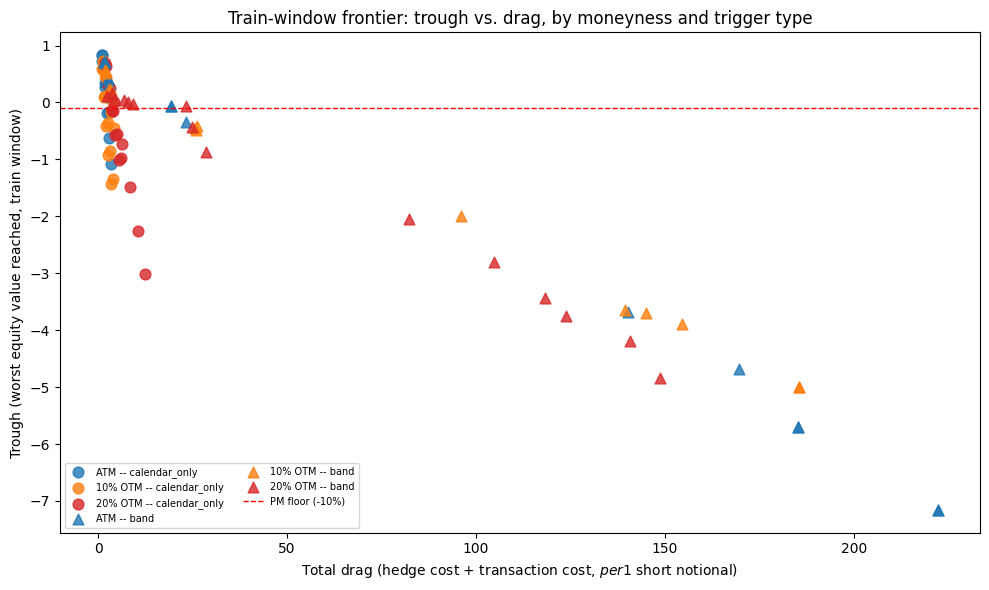

,coverage,moneyness,target_dte,roll_dte,trigger,trough,drag,band_rolls,misses,CAGR,Ann. Vol,Sharpe,Max DD,Calmar
4,1.0,ATM,180,30,calendar_only,0.832633,0.924442,0,0,0.476967,0.341238,1.554163,-0.160403,2.973559
5,1.0,ATM,180,30,band,0.715347,1.427287,2,0,-0.062091,0.408973,0.240780,-0.278669,-0.222812


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
markers = {"calendar_only": "o", "band": "^"}
colors = {"ATM": "tab:blue", "10% OTM": "tab:orange", "20% OTM": "tab:red"}

for trigger in TRIGGERS:
    for bucket in MONEYNESS_LIST:
        sub = sweep_train[(sweep_train["trigger"] == trigger) & (sweep_train["moneyness"] == bucket)]
        ax.scatter(sub["drag"], sub["trough"], marker=markers[trigger], color=colors[bucket],
                   s=60, alpha=0.8, label=f"{bucket} -- {trigger}")

ax.axhline(TROUGH_FLOOR, color="red", linestyle="--", linewidth=1, label="PM floor (-10%)")
ax.set_xlabel("Total drag (hedge cost + transaction cost, $ per $1 short notional)")
ax.set_ylabel("Trough (worst equity value reached, train window)")
ax.set_title("Train-window frontier: trough vs. drag, by moneyness and trigger type")
ax.legend(fontsize=7, loc="lower left", ncol=2)
fig.tight_layout()
plt.show()

def pick_best(df, trigger):
    sub = df[(df["trigger"] == trigger) & (df["trough"] >= TROUGH_FLOOR)]
    if sub.empty:
        print(f"No config with trigger={trigger} clears the -10% floor on the train window.")
        return None
    return sub.loc[sub["drag"].idxmin()]

best_calendar = pick_best(sweep_train, "calendar_only")
best_band = pick_best(sweep_train, "band")
pd.DataFrame([row for row in [best_calendar, best_band] if row is not None]).drop(columns="equity")


## Validation: freeze the chosen configs, run forward -- one continuous simulation

No re-fitting -- same exact `(coverage, moneyness, target_dte, roll_dte, trigger)` picked
from the train window. Earlier version of this cell re-based equity to 1.0 at the start of
the test window, which created a misleading artifact: TSLL jumped +10.4% on 2023-07-03 (the
test window's first trading day), so a fresh reset-to-1.0 there made the curve look like it
opened already near the -10% floor. Fixed by running **one continuous simulation from
TRAIN_START straight through TEST_END** -- equity is 1.0 only once, at the position's true
inception, and the test window is just a later slice of that same never-reset series. This
also removes the train/test cost-comparability issue (raw drag totals were previously
computed over very different window lengths, ~10 months vs. ~3 years).

Also now printing CAGR / Ann. Vol / Sharpe / Max DD / Calmar for context -- not the
selection criterion, but useful alongside trough/drag.

In [7]:
def validate(row, label):
    if row is None:
        return None, None
    trigger = row["trigger"]
    band = COVERAGE_BAND if trigger == "band" else None

    r_full = r_tsll_full.loc[TRAIN_START:TEST_END]
    cum_tsll_full = (1 + r_full).cumprod()

    equity, stats = simulate_convexity_coverage(
        r_full, cum_tsll_full, row["moneyness"], int(row["target_dte"]), int(row["roll_dte"]),
        coverage=row["coverage"], coverage_band=band, tsla_cost_pct=TSLA_COST_PCT,
    )

    train_slice = equity.loc[TRAIN_START:TRAIN_END]
    test_slice = equity.loc[TEST_START:TEST_END]
    crash2_slice = equity.loc[CRASH2_START:CRASH2_END]

    test_risk = summarize(test_slice, test_slice.pct_change().dropna(), "")
    full_risk = summarize(equity, equity.pct_change().dropna(), "")

    result = {
        "label": label,
        "coverage": row["coverage"], "moneyness": row["moneyness"],
        "target_dte": row["target_dte"], "roll_dte": row["roll_dte"], "trigger": trigger,
        "train_trough": float(train_slice.min()),
        "test_trough": float(test_slice.min()),
        "crash2_trough": float(crash2_slice.min()) if len(crash2_slice) else float("nan"),
        "total_drag": stats["total_drag"],
        "band_rolls_total": stats["coverage_band_rolls"],
        # full-period (true inception -> end of data) and test-only reference metrics
        "Full CAGR": full_risk["CAGR"], "Full Sharpe": full_risk["Sharpe"], "Full Max DD": full_risk["Max DD"],
        "Test CAGR": test_risk["CAGR"], "Test Sharpe": test_risk["Sharpe"], "Test Max DD": test_risk["Max DD"],
    }
    return result, equity

results = []
equities = {}
for row, label in [(best_calendar, "Calendar-only (best)"), (best_band, "Coverage-band (best)")]:
    r_, eq_ = validate(row, label)
    if r_ is not None:
        results.append(r_)
        equities[label] = eq_

validation_df = pd.DataFrame(results)
validation_df


,label,coverage,moneyness,target_dte,roll_dte,trigger,train_trough,test_trough,crash2_trough,total_drag,band_rolls_total,Full CAGR,Full Sharpe,Full Max DD,Test CAGR,Test Sharpe,Test Max DD
0,Calendar-only (best),1.0,ATM,180,30,calendar_only,0.832633,1.087983,1.099989,3.188361,0,0.038206,0.332518,-0.273345,0.050064,-0.085994,-0.273345
1,Coverage-band (best),1.0,ATM,180,30,band,0.715347,0.663599,0.809888,4.280289,4,-0.036044,0.152923,-0.356974,-0.046703,0.088587,-0.356974


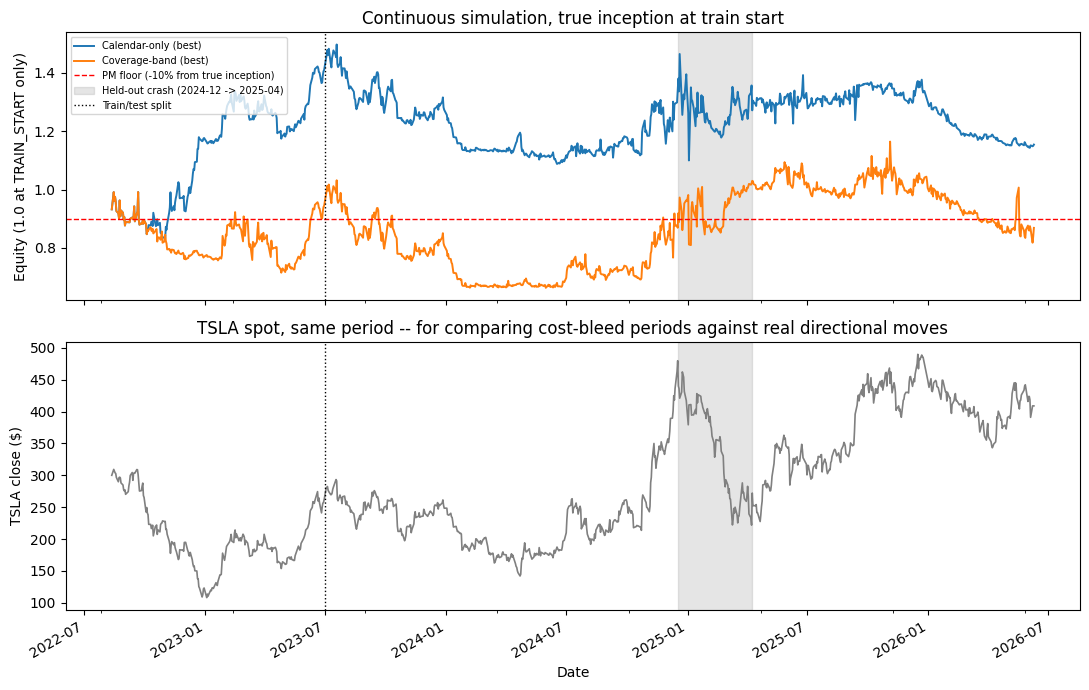

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

for label, eq in equities.items():
    eq.plot(ax=axes[0], label=label, linewidth=1.4)
axes[0].axhline(1 + TROUGH_FLOOR, color="red", linestyle="--", linewidth=1, label="PM floor (-10% from true inception)")
axes[0].axvspan(CRASH2_START, CRASH2_END, color="grey", alpha=0.2, label="Held-out crash (2024-12 -> 2025-04)")
axes[0].axvline(TEST_START, color="black", linestyle=":", linewidth=1, label="Train/test split")
axes[0].set_title("Continuous simulation, true inception at train start")
axes[0].set_ylabel("Equity (1.0 at TRAIN_START only)")
axes[0].legend(fontsize=7, loc="upper left")

tsla_spot_full.loc[TRAIN_START:TEST_END].plot(ax=axes[1], color="grey", linewidth=1.2)
axes[1].axvspan(CRASH2_START, CRASH2_END, color="grey", alpha=0.2)
axes[1].axvline(TEST_START, color="black", linestyle=":", linewidth=1)
axes[1].set_title("TSLA spot, same period -- for comparing cost-bleed periods against real directional moves")
axes[1].set_ylabel("TSLA close ($)")

fig.tight_layout()
plt.show()
